# WellPath Public-Health Data Visualizations

This notebook visualizes exploratory results derived from NHANES, CDC PLACES, and Statistics Canada CCHS. The values are currently treated as supplied research outputs and must be verified against the original datasets and analysis scripts before being presented as final findings.

This is a standalone research-visualization project. It does not connect to the WellPath application, backend, or database, and none of the supplied results are presented as clinically validated.

## Setup and output folders

The notebook uses `pathlib` to resolve paths relative to the notebook project and creates all output folders automatically.

In [4]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != "wellpath-data-research":
    candidate = PROJECT_ROOT / "wellpath-data-research"
    if candidate.exists():
        PROJECT_ROOT = candidate

DATA_DIR = PROJECT_ROOT / "data"
CHARTS_DIR = PROJECT_ROOT / "research-output" / "charts"
TABLES_DIR = PROJECT_ROOT / "research-output" / "tables"

for output_dir in (DATA_DIR, CHARTS_DIR, TABLES_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Charts: {CHARTS_DIR}")
print(f"Tables: {TABLES_DIR}")

Project root: C:\Users\Mahir\Desktop\WellPath\wellpath-data-research
Charts: C:\Users\Mahir\Desktop\WellPath\wellpath-data-research\research-output\charts
Tables: C:\Users\Mahir\Desktop\WellPath\wellpath-data-research\research-output\tables


## Central supplied research data

All values supplied for this visualization project are stored below without recalculation. The tidy table preserves dataset, period, sample, outcome, analysis, and verification metadata so each value remains auditable.

**Verification status: Needs review**

In [5]:
research_records = [
    # Family history, NHANES
    {"finding_group": "Family history", "item": "No family history", "value": 33.0, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,946 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Prevalence comparison", "verification_status": "Needs review", "notes": ""},
    {"finding_group": "Family history", "item": "Family history of diabetes", "value": 50.1, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,946 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Prevalence comparison", "verification_status": "Needs review", "notes": ""},
    # Risk score, NHANES
    {"finding_group": "Risk score groups", "item": "Low score 0–1", "value": 7.3, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,795 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Additive lifestyle, family-history, and demographic score", "verification_status": "Needs review", "notes": "Reported AUC: 0.71"},
    {"finding_group": "Risk score groups", "item": "Score 2–3", "value": 27.1, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,795 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Additive lifestyle, family-history, and demographic score", "verification_status": "Needs review", "notes": "Reported AUC: 0.71"},
    {"finding_group": "Risk score groups", "item": "Score 4–5", "value": 48.2, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,795 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Additive lifestyle, family-history, and demographic score", "verification_status": "Needs review", "notes": "Reported AUC: 0.71"},
    {"finding_group": "Risk score groups", "item": "High score 6+", "value": 68.3, "unit": "percent", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,795 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Additive lifestyle, family-history, and demographic score", "verification_status": "Needs review", "notes": "Reported AUC: 0.71"},
    # Adjusted risk drivers, NHANES
    *[
        {"finding_group": "Adjusted risk drivers", "item": item, "value": value, "unit": "adjusted odds ratio", "dataset": "NHANES", "year": "2017–2018", "sample_size": "3,892 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Mutually adjusted logistic regression", "verification_status": "Needs review", "notes": "Reported full-model AUC: 0.78"}
        for item, value in [
            ("Older age", 2.67),
            ("Family history of diabetes", 2.00),
            ("Higher BMI", 1.63),
            ("Higher resting heart rate", 1.20),
            ("Higher blood pressure", 1.12),
            ("More sleep", 0.88),
            ("Vigorous activity", 0.81),
            ("Being female", 0.68),
        ]
    ],
    # Model comparison
    {"finding_group": "Model comparison", "item": "Simple risk score AUC", "value": 0.71, "unit": "AUC", "dataset": "NHANES", "year": "2017–2018", "sample_size": "4,795 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Model discrimination comparison", "verification_status": "Needs review", "notes": ""},
    {"finding_group": "Model comparison", "item": "Full KPI model AUC", "value": 0.78, "unit": "AUC", "dataset": "NHANES", "year": "2017–2018", "sample_size": "3,892 adults", "outcome": "HbA1c greater than or equal to 5.7%", "analysis": "Model discrimination comparison", "verification_status": "Needs review", "notes": ""},
    # County prevalence, CDC PLACES
    *[
        {"finding_group": "County diabetes prevalence", "item": item, "value": value, "unit": "percent", "dataset": "CDC PLACES", "year": "2025", "sample_size": "2,956 US counties", "outcome": "Estimated diagnosed diabetes prevalence", "analysis": "County-level prevalence comparison", "verification_status": "Needs review", "notes": category}
        for item, value, category in [
            ("Greene, Alabama", 27.1, "High-prevalence county"),
            ("Sharkey, Mississippi", 25.2, "High-prevalence county"),
            ("Tensas, Louisiana", 25.1, "High-prevalence county"),
            ("US median county", 13.3, "US median"),
            ("Douglas, Colorado", 6.8, "Low-prevalence county"),
            ("Madison, Idaho", 4.9, "Low-prevalence county"),
        ]
    ],
    # County correlations
    *[
        {"finding_group": "County correlations", "item": item, "value": value, "unit": "Pearson correlation coefficient", "dataset": "CDC PLACES", "year": "2025", "sample_size": "2,956 US counties", "outcome": "Diagnosed diabetes prevalence", "analysis": "County-level correlation with diagnosed diabetes prevalence", "verification_status": "Needs review", "notes": ""}
        for item, value in [
            ("High blood pressure", 0.89),
            ("Physical inactivity", 0.85),
            ("Current smoking", 0.71),
            ("Obesity", 0.67),
        ]
    ],
    # Canadian provincial prevalence
    *[
        {"finding_group": "Canadian diabetes prevalence", "item": item, "value": value, "unit": "percent", "dataset": "Statistics Canada CCHS", "year": "2019–2020", "sample_size": "Weighted population: 32.1 million Canadians", "outcome": "Self-reported diabetes prevalence", "analysis": "Survey-weighted provincial comparison", "verification_status": "Needs review", "notes": ""}
        for item, value in [
            ("Newfoundland and Labrador", 8.5),
            ("New Brunswick", 7.7),
            ("Ontario", 7.1),
            ("Nova Scotia", 7.0),
            ("Quebec", 6.6),
            ("Alberta", 6.2),
            ("Prince Edward Island", 6.1),
            ("Manitoba", 5.1),
            ("British Columbia", 4.9),
            ("Saskatchewan", 4.6),
            ("Territories", 1.6),
        ]
    ],
    # Adjusted geography
    {"finding_group": "Adjusted geography", "item": "Newfoundland versus Ontario adjusted odds ratio", "value": 1.09, "unit": "adjusted odds ratio", "dataset": "Statistics Canada CCHS", "year": "2019–2020", "sample_size": "86,893", "outcome": "Self-reported diabetes", "analysis": "Adjusted logistic regression", "verification_status": "Needs review", "notes": "Adjusted for age, weight, income, smoking, and stress"},
    {"finding_group": "Adjusted geography", "item": "Prediction gain after adding province", "value": 0.003, "unit": "change in model performance (exact metric not supplied)", "dataset": "Statistics Canada CCHS", "year": "2019–2020", "sample_size": "86,893", "outcome": "Self-reported diabetes", "analysis": "Model comparison", "verification_status": "Needs review", "notes": "Adjusted for age, weight, income, smoking, and stress"},
    # Weight class
    {"finding_group": "Weight-class comparison", "item": "Normal or underweight", "value": 3.7, "unit": "percent", "dataset": "Statistics Canada CCHS", "year": "2019–2020", "sample_size": "Not supplied", "outcome": "Self-reported diabetes prevalence", "analysis": "Survey-weighted prevalence by weight class", "verification_status": "Needs review", "notes": ""},
    {"finding_group": "Weight-class comparison", "item": "Overweight or obese", "value": 9.4, "unit": "percent", "dataset": "Statistics Canada CCHS", "year": "2019–2020", "sample_size": "Not supplied", "outcome": "Self-reported diabetes prevalence", "analysis": "Survey-weighted prevalence by weight class", "verification_status": "Needs review", "notes": ""},
]

research_results = pd.DataFrame(research_records)
research_results.to_csv(DATA_DIR / "research_results.csv", index=False)
display(research_results)
print(f"Saved {len(research_results)} supplied values to {DATA_DIR / 'research_results.csv'}")

,finding_group,item,value,unit,dataset,year,sample_size,outcome,analysis,verification_status,notes
0,Family history,No family history,33.000,percent,NHANES,2017–2018,"4,946 adults",HbA1c greater than or equal to 5.7%,Prevalence comparison,Needs review,
1,Family history,Family history of diabetes,50.100,percent,NHANES,2017–2018,"4,946 adults",HbA1c greater than or equal to 5.7%,Prevalence comparison,Needs review,
2,Risk score groups,Low score 0–1,7.300,percent,NHANES,2017–2018,"4,795 adults",HbA1c greater than or equal to 5.7%,"Additive lifestyle, family-history, and demogr...",Needs review,Reported AUC: 0.71
3,Risk score groups,Score 2–3,27.100,percent,NHANES,2017–2018,"4,795 adults",HbA1c greater than or equal to 5.7%,"Additive lifestyle, family-history, and demogr...",Needs review,Reported AUC: 0.71
4,Risk score groups,Score 4–5,48.200,percent,NHANES,2017–2018,"4,795 adults",HbA1c greater than or equal to 5.7%,"Additive lifestyle, family-history, and demogr...",Needs review,Reported AUC: 0.71
5,Risk score groups,High score 6+,68.300,percent,NHANES,2017–2018,"4,795 adults",HbA1c greater than or equal to 5.7%,"Additive lifestyle, family-history, and demogr...",Needs review,Reported AUC: 0.71
6,Adjusted risk drivers,Older age,2.670,adjusted odds ratio,NHANES,2017–2018,"3,892 adults",HbA1c greater than or equal to 5.7%,Mutually adjusted logistic regression,Needs review,Reported full-model AUC: 0.78
7,Adjusted risk drivers,Family history of diabetes,2.000,adjusted odds ratio,NHANES,2017–2018,"3,892 adults",HbA1c greater than or equal to 5.7%,Mutually adjusted logistic regression,Needs review,Reported full-model AUC: 0.78
8,Adjusted risk drivers,Higher BMI,1.630,adjusted odds ratio,NHANES,2017–2018,"3,892 adults",HbA1c greater than or equal to 5.7%,Mutually adjusted logistic regression,Needs review,Reported full-model AUC: 0.78
9,Adjusted risk drivers,Higher resting heart rate,1.200,adjusted odds ratio,NHANES,2017–2018,"3,892 adults",HbA1c greater than or equal to 5.7%,Mutually adjusted logistic regression,Needs review,Reported full-model AUC: 0.78


Saved 41 supplied values to C:\Users\Mahir\Desktop\WellPath\wellpath-data-research\data\research_results.csv


## Reusable chart helpers

The label helper adds exact numeric values to horizontal or vertical bars. Matplotlib defaults are retained: no style or chart colors are manually specified.

In [6]:
def add_bar_value_labels(ax, orientation="vertical", decimals=1, suffix=""):
    for bar in ax.patches:
        if orientation == "horizontal":
            value = bar.get_width()
            ax.annotate(
                f"{value:.{decimals}f}{suffix}",
                (value, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
            )
        else:
            value = bar.get_height()
            ax.annotate(
                f"{value:.{decimals}f}{suffix}",
                (bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
            )


def supplied_group(name):
    return research_results.loc[
        research_results["finding_group"].eq(name)
    ].reset_index(drop=True)

## 1. Family history and measured blood-sugar outcome

**Verification status: Needs review**

- **Dataset / year:** NHANES, 2017–2018
- **Sample size:** 4,946 adults
- **Outcome definition:** HbA1c greater than or equal to 5.7%
- **Analysis method:** Prevalence comparison

Adults reporting a family history of diabetes had a higher measured prevalence of HbA1c-defined prediabetes or diabetes in the supplied analysis.

**Limitation:** This is an association and does not show that family history alone caused the measured outcome.

,Family-history group,Prevalence (%)
0,No family history,33.0
1,Family history of diabetes,50.1


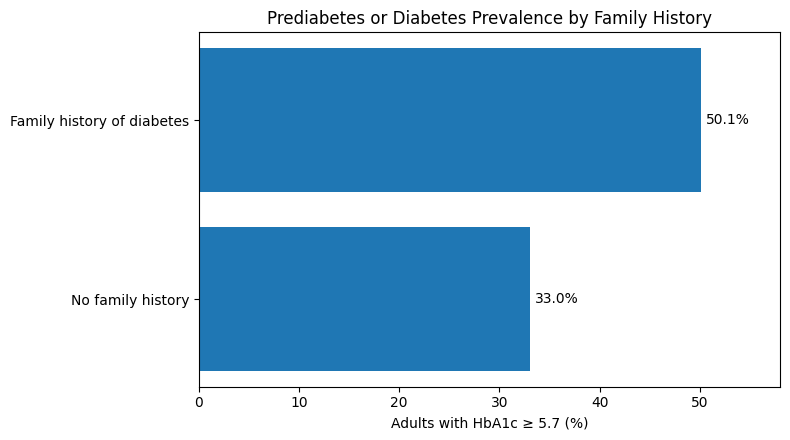

In [7]:
family_history_df = supplied_group("Family history")[["item", "value"]].rename(
    columns={"item": "Family-history group", "value": "Prevalence (%)"}
)
display(family_history_df)

plt.figure(figsize=(8, 4.5))
ax = plt.gca()
ax.barh(family_history_df["Family-history group"], family_history_df["Prevalence (%)"])
ax.set_title("Prediabetes or Diabetes Prevalence by Family History")
ax.set_xlabel("Adults with HbA1c ≥ 5.7 (%)")
ax.set_xlim(0, 58)
add_bar_value_labels(ax, orientation="horizontal", decimals=1, suffix="%")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "family_history_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 2. Additive risk-score gradient

**Verification status: Needs review**

- **Dataset / year:** NHANES, 2017–2018
- **Sample size:** 4,795 adults
- **Outcome definition:** HbA1c greater than or equal to 5.7%
- **Analysis method:** Additive lifestyle, family-history, and demographic score

The measured outcome rate increased across the supplied risk-score categories.

**Limitation:** The score definition, thresholds, survey weighting, and validation method must be verified.

,Risk-score group,Prevalence (%)
0,Low score 0–1,7.3
1,Score 2–3,27.1
2,Score 4–5,48.2
3,High score 6+,68.3


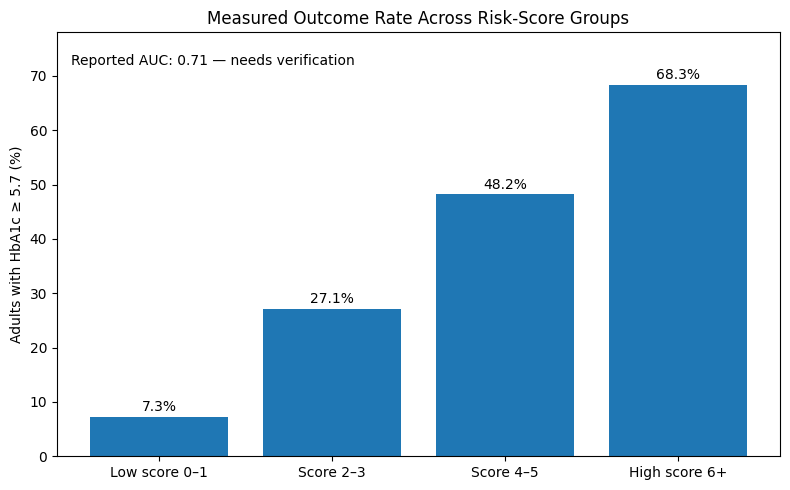

In [8]:
risk_score_df = supplied_group("Risk score groups")[["item", "value"]].rename(
    columns={"item": "Risk-score group", "value": "Prevalence (%)"}
)
display(risk_score_df)

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(risk_score_df["Risk-score group"], risk_score_df["Prevalence (%)"])
ax.set_title("Measured Outcome Rate Across Risk-Score Groups")
ax.set_ylabel("Adults with HbA1c ≥ 5.7 (%)")
ax.set_ylim(0, 78)
add_bar_value_labels(ax, decimals=1, suffix="%")
ax.annotate("Reported AUC: 0.71 — needs verification", xy=(0.02, 0.95), xycoords="axes fraction", va="top")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "risk_score_gradient.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 3. Adjusted odds ratios

**Verification status: Needs review**

- **Dataset / year:** NHANES, 2017–2018
- **Sample size:** 3,892 adults
- **Outcome definition:** HbA1c greater than or equal to 5.7%
- **Analysis method:** Mutually adjusted logistic regression

Values above 1 indicate higher adjusted odds in the supplied model; values below 1 indicate lower adjusted odds.

**Limitation:** Confidence intervals and p-values were not supplied and must be added before drawing conclusions about statistical significance.

,Predictor,Adjusted odds ratio
0,Older age,2.67
1,Family history of diabetes,2.00
2,Higher BMI,1.63
3,Higher resting heart rate,1.20
4,Higher blood pressure,1.12
5,More sleep,0.88
6,Vigorous activity,0.81
7,Being female,0.68


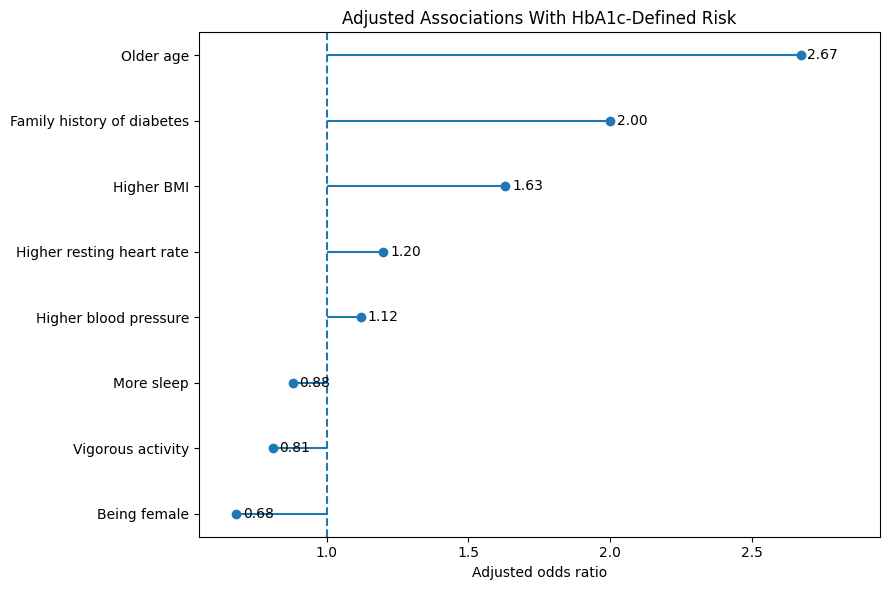

In [9]:
adjusted_or_df = (
    supplied_group("Adjusted risk drivers")[["item", "value"]]
    .rename(columns={"item": "Predictor", "value": "Adjusted odds ratio"})
    .sort_values("Adjusted odds ratio", ascending=False)
    .reset_index(drop=True)
)
display(adjusted_or_df)

plt.figure(figsize=(9, 6))
ax = plt.gca()
y_positions = np.arange(len(adjusted_or_df))
ax.hlines(y_positions, 1.0, adjusted_or_df["Adjusted odds ratio"])
ax.scatter(adjusted_or_df["Adjusted odds ratio"], y_positions)
ax.axvline(1.0, linestyle="--")
ax.set_yticks(y_positions, adjusted_or_df["Predictor"])
ax.invert_yaxis()
ax.set_xlim(0.55, 2.95)
ax.set_xlabel("Adjusted odds ratio")
ax.set_title("Adjusted Associations With HbA1c-Defined Risk")
for y, value in zip(y_positions, adjusted_or_df["Adjusted odds ratio"]):
    ax.annotate(f"{value:.2f}", (value, y), xytext=(5, 0), textcoords="offset points", va="center")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "adjusted_odds_ratios.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 4. Simple score versus full model

**Verification status: Needs review**

- **Dataset / year:** NHANES, 2017–2018
- **Sample sizes:** Simple score: 4,795 adults; full KPI model: 3,892 adults
- **Outcome definition:** HbA1c greater than or equal to 5.7%
- **Analysis method:** Model discrimination comparison

The supplied full model had a higher reported AUC than the additive score.

**Limitation:** The validation method is not confirmed. Do not label either result as cross-validated unless the source scripts prove it.

,Model,Reported AUC
0,Simple risk score,0.71
1,Full KPI model,0.78


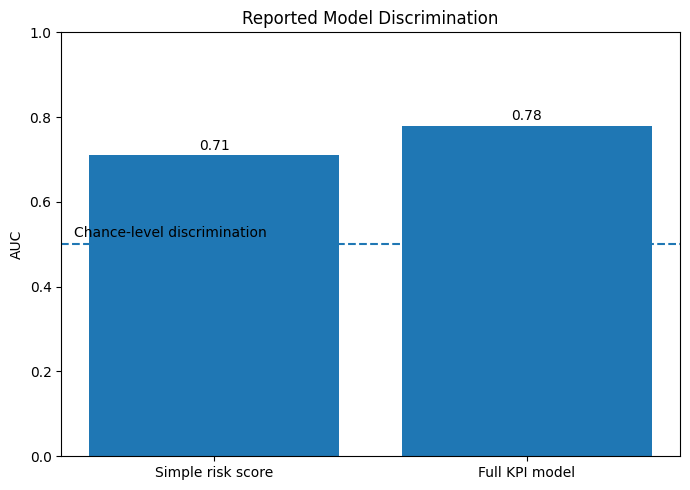

In [10]:
model_auc_df = supplied_group("Model comparison")[["item", "value"]].copy()
model_auc_df["item"] = model_auc_df["item"].str.replace(" AUC", "", regex=False)
model_auc_df = model_auc_df.rename(columns={"item": "Model", "value": "Reported AUC"})
display(model_auc_df)

plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.bar(model_auc_df["Model"], model_auc_df["Reported AUC"])
ax.axhline(0.5, linestyle="--")
ax.text(0.02, 0.51, "Chance-level discrimination", transform=ax.get_yaxis_transform(), va="bottom")
ax.set_ylim(0, 1)
ax.set_ylabel("AUC")
ax.set_title("Reported Model Discrimination")
add_bar_value_labels(ax, decimals=2)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "model_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 5. Selected US county diabetes prevalence

**Verification status: Needs review**

- **Dataset / year:** CDC PLACES, 2025 release
- **Coverage:** 2,956 US counties
- **Outcome definition:** Estimated diagnosed diabetes prevalence
- **Analysis method:** County-level prevalence comparison

The supplied selected counties span high-prevalence estimates, the US median county, and low-prevalence estimates.

**Required warning / limitation:** These are county-level population estimates. They must not be interpreted as an individual resident’s personal diabetes risk.

,County or benchmark,Prevalence (%),Category
0,"Greene, Alabama",27.1,High-prevalence county
1,"Sharkey, Mississippi",25.2,High-prevalence county
2,"Tensas, Louisiana",25.1,High-prevalence county
3,US median county,13.3,US median
4,"Douglas, Colorado",6.8,Low-prevalence county
5,"Madison, Idaho",4.9,Low-prevalence county


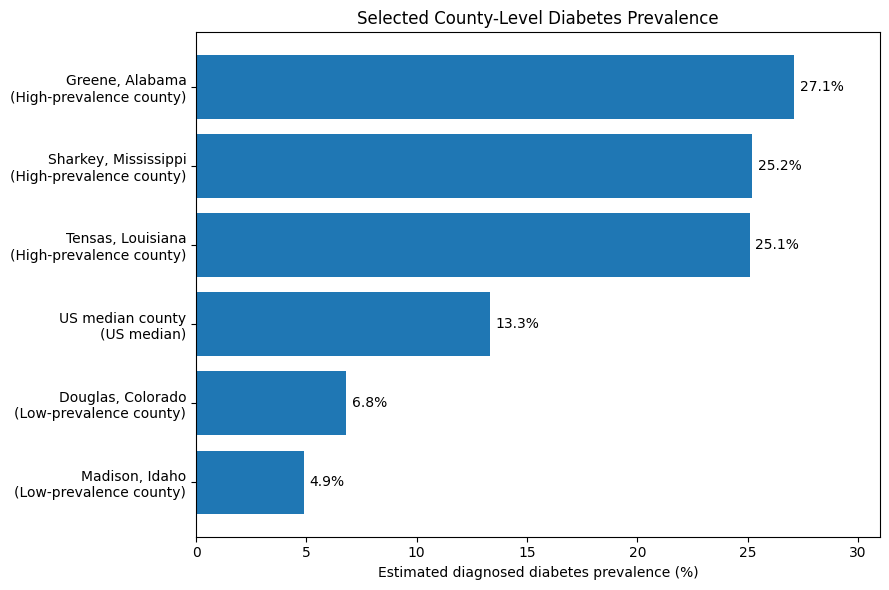

In [11]:
county_prevalence_df = supplied_group("County diabetes prevalence")[["item", "value", "notes"]].rename(
    columns={"item": "County or benchmark", "value": "Prevalence (%)", "notes": "Category"}
).sort_values("Prevalence (%)", ascending=False).reset_index(drop=True)
display(county_prevalence_df)

chart_labels = county_prevalence_df["County or benchmark"] + "\n(" + county_prevalence_df["Category"] + ")"
plt.figure(figsize=(9, 6))
ax = plt.gca()
ax.barh(chart_labels, county_prevalence_df["Prevalence (%)"])
ax.invert_yaxis()
ax.set_xlim(0, 31)
ax.set_xlabel("Estimated diagnosed diabetes prevalence (%)")
ax.set_title("Selected County-Level Diabetes Prevalence")
add_bar_value_labels(ax, orientation="horizontal", decimals=1, suffix="%")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "county_diabetes_prevalence.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 6. County-level risk-factor correlations

**Verification status: Needs review**

- **Dataset / year:** CDC PLACES, 2025 release
- **Coverage:** 2,956 US counties
- **Outcome definition:** Diagnosed diabetes prevalence
- **Analysis method:** County-level Pearson correlation with diagnosed diabetes prevalence

Counties with higher estimated diabetes prevalence also tended to have higher prevalence of these population-level risk factors.

**Warning / limitation:** County-level correlations cannot establish individual-level relationships or causation.

,Population-level risk factor,Pearson correlation coefficient
0,High blood pressure,0.89
1,Physical inactivity,0.85
2,Current smoking,0.71
3,Obesity,0.67


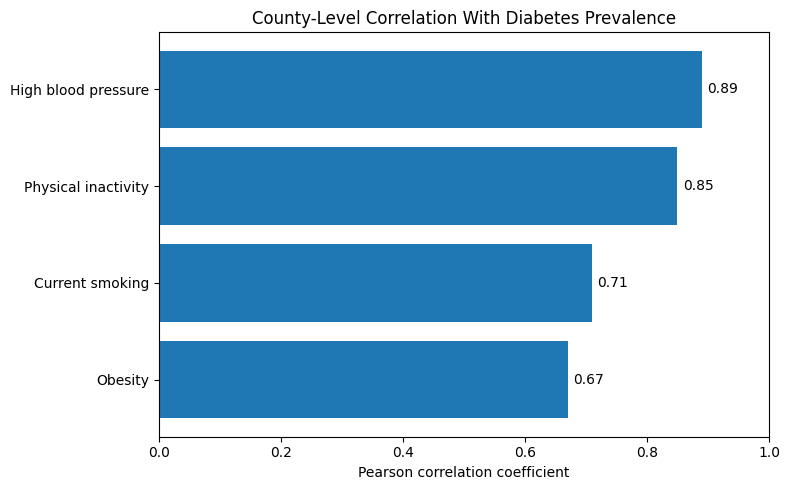

In [12]:
county_correlation_df = (
    supplied_group("County correlations")[["item", "value"]]
    .rename(columns={"item": "Population-level risk factor", "value": "Pearson correlation coefficient"})
    .sort_values("Pearson correlation coefficient", ascending=False)
    .reset_index(drop=True)
)
display(county_correlation_df)

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.barh(county_correlation_df["Population-level risk factor"], county_correlation_df["Pearson correlation coefficient"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Pearson correlation coefficient")
ax.set_title("County-Level Correlation With Diabetes Prevalence")
add_bar_value_labels(ax, orientation="horizontal", decimals=2)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "county_risk_correlations.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 7. Canadian provincial diabetes prevalence

**Verification status: Needs review**

- **Dataset / year:** Statistics Canada CCHS, 2019–2020
- **Reported weighted population:** 32.1 million Canadians
- **Outcome definition:** Self-reported diabetes prevalence
- **Analysis method:** Survey-weighted provincial comparison

The supplied estimates show regional differences in self-reported diabetes prevalence.

**Limitation:** Differences may reflect age structure, population characteristics, access to care, reporting patterns, and other confounding factors.

,Province or region,Prevalence (%)
0,Newfoundland and Labrador,8.5
1,New Brunswick,7.7
2,Ontario,7.1
3,Nova Scotia,7.0
4,Quebec,6.6
5,Alberta,6.2
6,Prince Edward Island,6.1
7,Manitoba,5.1
8,British Columbia,4.9
9,Saskatchewan,4.6


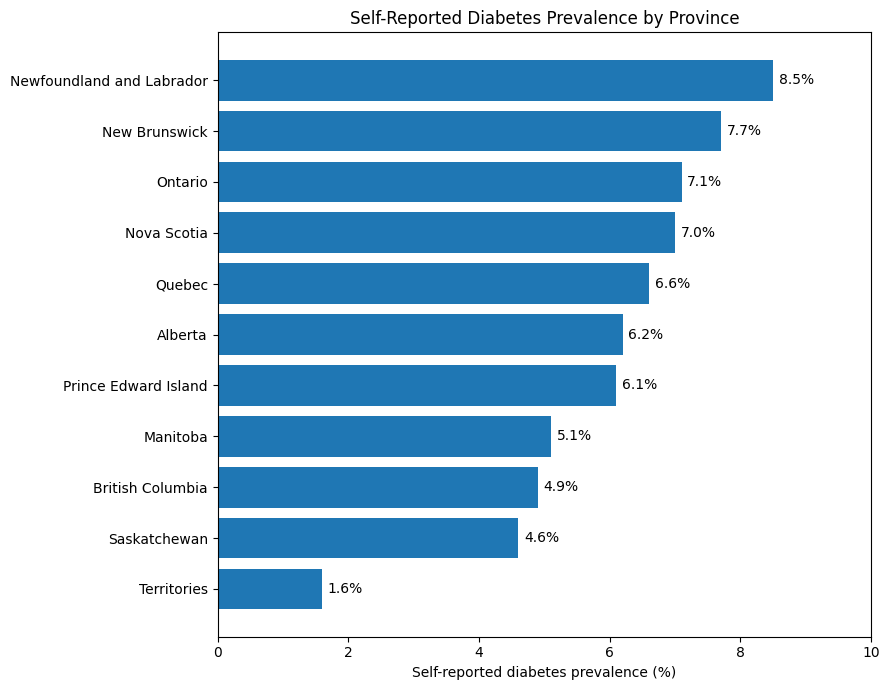

In [13]:
canada_prevalence_df = (
    supplied_group("Canadian diabetes prevalence")[["item", "value"]]
    .rename(columns={"item": "Province or region", "value": "Prevalence (%)"})
    .sort_values("Prevalence (%)", ascending=False)
    .reset_index(drop=True)
)
display(canada_prevalence_df)

plt.figure(figsize=(9, 7))
ax = plt.gca()
ax.barh(canada_prevalence_df["Province or region"], canada_prevalence_df["Prevalence (%)"])
ax.invert_yaxis()
ax.set_xlim(0, 10)
ax.set_xlabel("Self-reported diabetes prevalence (%)")
ax.set_title("Self-Reported Diabetes Prevalence by Province")
add_bar_value_labels(ax, orientation="horizontal", decimals=1, suffix="%")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "canadian_province_prevalence.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 8. Geography before and after adjustment

**Verification status: Needs review**

- **Dataset / year:** Statistics Canada CCHS, 2019–2020
- **Sample size:** 86,893
- **Outcome definition:** Self-reported diabetes
- **Adjustments:** Age, weight, income, smoking, and stress
- **Analysis method:** Adjusted logistic regression and model comparison

After adjustment for the supplied individual-level variables, province appeared to add little predictive information.

The reported `0.003` is treated as a change in model performance, but the exact metric must be verified.

**Limitation:** The exact model-performance metric behind the reported 0.003 gain was not supplied.

,Metric,Supplied value,Unit or interpretation
0,Newfoundland versus Ontario adjusted odds ratio,1.090,adjusted odds ratio
1,Prediction gain after adding province,0.003,change in model performance (exact metric not ...


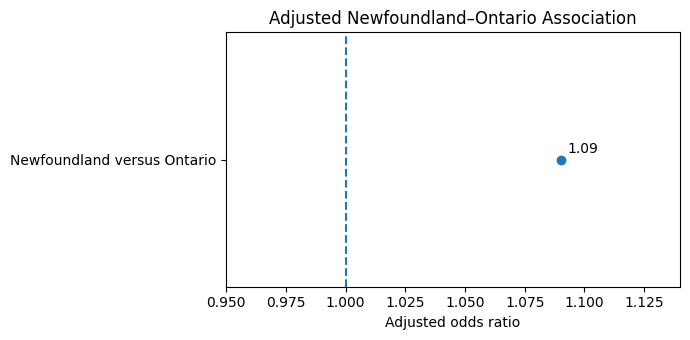

In [14]:
adjusted_geography_df = supplied_group("Adjusted geography")[["item", "value", "unit"]].rename(
    columns={"item": "Metric", "value": "Supplied value", "unit": "Unit or interpretation"}
)
display(adjusted_geography_df)

geography_or = float(adjusted_geography_df.loc[
    adjusted_geography_df["Metric"].str.contains("odds ratio"), "Supplied value"
].iloc[0])

plt.figure(figsize=(7, 3.5))
ax = plt.gca()
ax.scatter([geography_or], [0])
ax.axvline(1.0, linestyle="--")
ax.set_xlim(0.95, 1.14)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([0], ["Newfoundland versus Ontario"])
ax.set_xlabel("Adjusted odds ratio")
ax.set_title("Adjusted Newfoundland–Ontario Association")
ax.annotate(f"{geography_or:.2f}", (geography_or, 0), xytext=(5, 5), textcoords="offset points")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "adjusted_geography_odds_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

,Metric,Change in model performance
0,Prediction gain after adding province,0.003


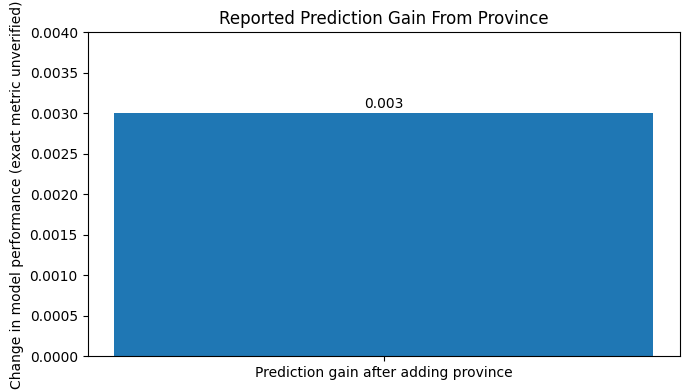

In [15]:
prediction_gain = float(adjusted_geography_df.loc[
    adjusted_geography_df["Metric"].str.contains("Prediction gain"), "Supplied value"
].iloc[0])

geography_gain_df = pd.DataFrame(
    {"Metric": ["Prediction gain after adding province"], "Change in model performance": [prediction_gain]}
)
display(geography_gain_df)

plt.figure(figsize=(7, 4))
ax = plt.gca()
ax.bar(geography_gain_df["Metric"], geography_gain_df["Change in model performance"])
ax.set_ylim(0, 0.004)
ax.set_ylabel("Change in model performance (exact metric unverified)")
ax.set_title("Reported Prediction Gain From Province")
add_bar_value_labels(ax, decimals=3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "geography_prediction_gain.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 9. Weight class and diabetes prevalence

**Verification status: Needs review**

- **Dataset / year:** Statistics Canada CCHS, 2019–2020
- **Sample size:** Not supplied
- **Outcome definition:** Self-reported diabetes prevalence
- **Analysis method:** Survey-weighted prevalence by weight class

The supplied analysis showed higher self-reported diabetes prevalence in the overweight or obese group.

**Limitation:** This is an unadjusted group comparison and does not prove that weight class alone caused the difference.

,Weight class,Prevalence (%)
0,Normal or underweight,3.7
1,Overweight or obese,9.4


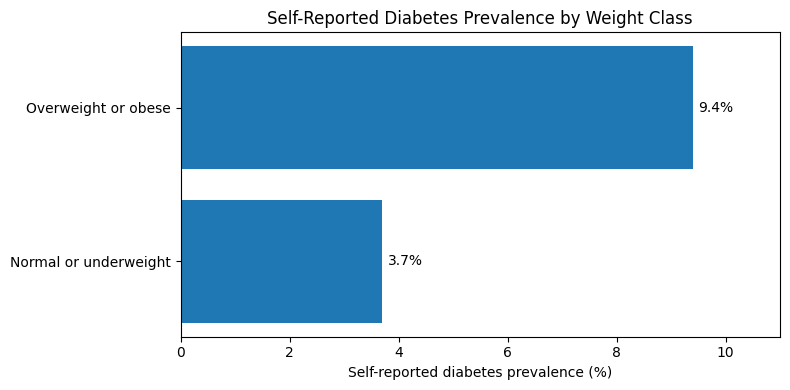

In [16]:
weight_class_df = supplied_group("Weight-class comparison")[["item", "value"]].rename(
    columns={"item": "Weight class", "value": "Prevalence (%)"}
)
display(weight_class_df)

plt.figure(figsize=(8, 4))
ax = plt.gca()
ax.barh(weight_class_df["Weight class"], weight_class_df["Prevalence (%)"])
ax.set_xlim(0, 11)
ax.set_xlabel("Self-reported diabetes prevalence (%)")
ax.set_title("Self-Reported Diabetes Prevalence by Weight Class")
add_bar_value_labels(ax, orientation="horizontal", decimals=1, suffix="%")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "weight_class_prevalence.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Summary: research-to-product mapping

The table below maps the supplied exploratory findings to possible WellPath fields or features. These are design-context mappings, not clinical recommendations.

**Verification status: Needs review**

In [17]:
wellpath_research_mapping = pd.DataFrame(
    [
        ["Family history association", "NHANES", "Optional family-history onboarding questions", "Background risk context", "Must not be treated as genetic testing", "Needs review"],
        ["Risk-score gradient", "NHANES", "Transparent baseline risk score", "Simple explainable comparison", "Requires documented scoring thresholds and validation", "Needs review"],
        ["Adjusted multivariable model", "NHANES", "Combined KPI analysis", "Shows why factors should be analyzed together", "Odds ratios need confidence intervals", "Needs review"],
        ["County geographic variation", "CDC PLACES", "Optional broad regional context", "Population-health comparison", "Must not become individual risk", "Needs review"],
        ["County correlations", "CDC PLACES", "Population-level context", "Shows risk factors clustering geographically", "Ecological fallacy risk", "Needs review"],
        ["Provincial prevalence", "Statistics Canada CCHS", "Canadian regional research context", "Supports geography discussion", "Province may act as a proxy for population makeup", "Needs review"],
        ["Adjusted geography result", "Statistics Canada CCHS", "Low-weight geography variable", "Avoid overvaluing location", "Exact model metric must be verified", "Needs review"],
        ["Weight-class difference", "Statistics Canada CCHS", "Weight and BMI context", "Lifestyle and clinical interpretation", "Association is not causation", "Needs review"],
    ],
    columns=[
        "Research finding",
        "Dataset",
        "WellPath field or feature supported",
        "Possible use",
        "Important limitation",
        "Verification status",
    ],
)

display(wellpath_research_mapping)
mapping_path = TABLES_DIR / "wellpath_research_mapping.csv"
wellpath_research_mapping.to_csv(mapping_path, index=False)
print(f"Saved mapping table to {mapping_path}")

,Research finding,Dataset,WellPath field or feature supported,Possible use,Important limitation,Verification status
0,Family history association,NHANES,Optional family-history onboarding questions,Background risk context,Must not be treated as genetic testing,Needs review
1,Risk-score gradient,NHANES,Transparent baseline risk score,Simple explainable comparison,Requires documented scoring thresholds and val...,Needs review
2,Adjusted multivariable model,NHANES,Combined KPI analysis,Shows why factors should be analyzed together,Odds ratios need confidence intervals,Needs review
3,County geographic variation,CDC PLACES,Optional broad regional context,Population-health comparison,Must not become individual risk,Needs review
4,County correlations,CDC PLACES,Population-level context,Shows risk factors clustering geographically,Ecological fallacy risk,Needs review
5,Provincial prevalence,Statistics Canada CCHS,Canadian regional research context,Supports geography discussion,Province may act as a proxy for population makeup,Needs review
6,Adjusted geography result,Statistics Canada CCHS,Low-weight geography variable,Avoid overvaluing location,Exact model metric must be verified,Needs review
7,Weight-class difference,Statistics Canada CCHS,Weight and BMI context,Lifestyle and clinical interpretation,Association is not causation,Needs review


Saved mapping table to C:\Users\Mahir\Desktop\WellPath\wellpath-data-research\research-output\tables\wellpath_research_mapping.csv


## Verification reminder

Every value in this notebook remains **Needs review**. Confirm the original dataset extracts, variable definitions, survey weights, cohort filters, scoring thresholds, regression specifications, uncertainty estimates, and validation procedures before treating any result as final. The reported `0.003` geography prediction gain requires its exact performance metric to be identified.